In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC

In [2]:
iris = load_iris()

In [3]:
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

In [4]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


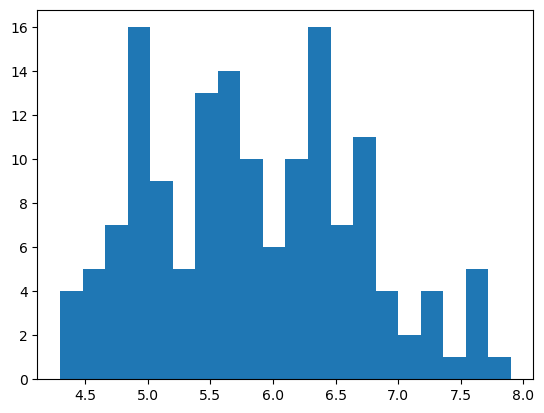

In [6]:
#Histogram of the data --> need a scatter plot instead
plt.hist(df_iris['sepal length (cm)'], bins=20)
plt.show()

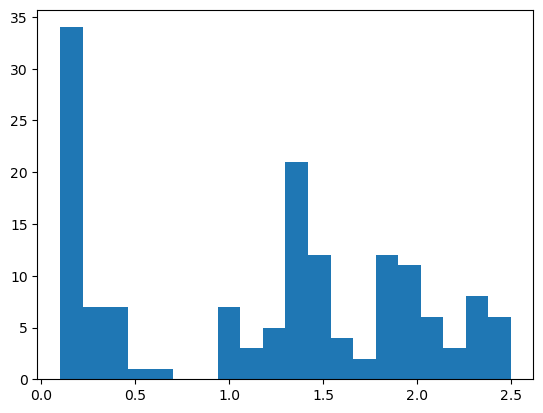

In [7]:
#Histogram of the data --> need a scatter plot instead
plt.hist(df_iris['petal width (cm)'], bins=20)
plt.show()

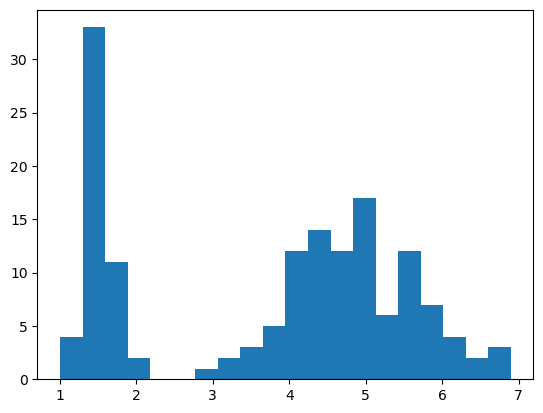

In [8]:
#Histogram of the data --> need a scatter plot instead
plt.hist(df_iris['petal length (cm)'], bins=20)
plt.show()

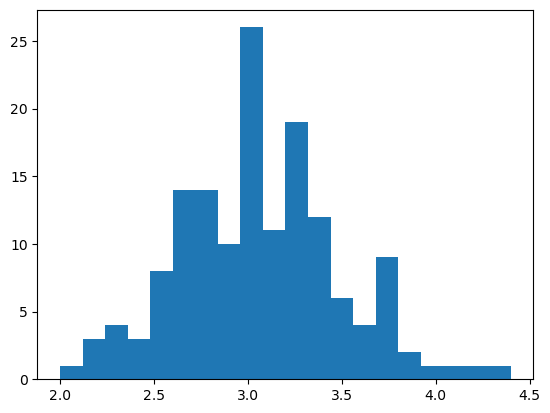

In [9]:
#Histogram of the data --> need a scatter plot instead
plt.hist(df_iris['sepal width (cm)'], bins=20)
plt.show()

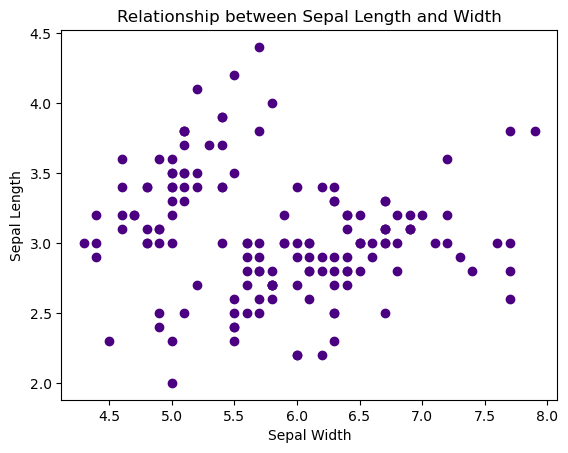

In [10]:
plt.scatter(df_iris['sepal length (cm)'], df_iris['sepal width (cm)'], color='indigo')
plt.title('Relationship between Sepal Length and Width')
plt.xlabel('Sepal Width')
plt.ylabel('Sepal Length')
plt.show()

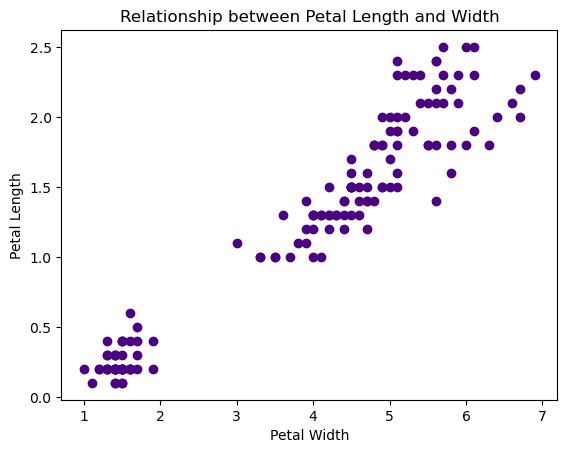

In [11]:
#Checking for scatter plots
plt.scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'], color='indigo')
plt.title('Relationship between Petal Length and Width')
plt.xlabel('Petal Width')
plt.ylabel('Petal Length')
plt.show()

In [12]:
iris_corr = df_iris.corr()

<Axes: >

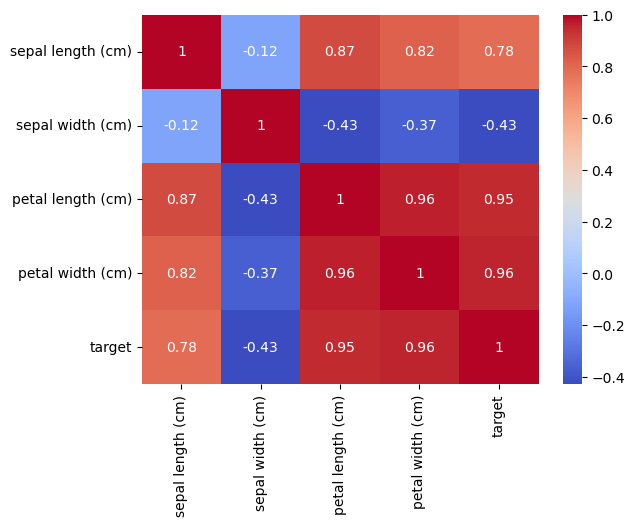

In [13]:
#Plotting correlation matrix heatmap
sns.heatmap(iris_corr, annot=True, cmap='coolwarm')

In [14]:
#Checking for any missing values
df_iris.isnull().any()

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
target               False
dtype: bool

In [15]:
#Transferring to X and y while keeping everything in the same array
X = df_iris[['sepal length (cm)', 'petal length (cm)', 'petal width (cm)']]
y = df_iris['target']

In [16]:
# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [17]:
X_train

,sepal length (cm),petal length (cm),petal width (cm)
35,5.0,1.2,0.2
52,6.9,4.9,1.5
76,6.8,4.8,1.4
94,5.6,4.2,1.3
72,6.3,4.9,1.5
...,...,...,...
81,5.5,3.7,1.0
12,4.8,1.4,0.1
97,6.2,4.3,1.3
133,6.3,5.1,1.5


In [18]:
#Scaling for better train of the model
scaler = StandardScaler()
scaler.fit(X_train) #Only for X training data. Y doesnt need scaling and X_test cannot be leaked
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test) 

## Training Using Different Models

In [43]:
#KNN Classifier
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train_scaled,y_train)
y_pred_neigh = neigh.predict(X_test_scaled)

In [44]:
accuracy = accuracy_score(y_test, y_pred_neigh)
confusion = confusion_matrix(y_test, y_pred_neigh)

In [45]:
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [46]:
print("Confusion Matrix", confusion)

Confusion Matrix [[ 7  0  0]
 [ 0  9  2]
 [ 0  0 12]]


In [67]:
#Logistic Regression
logreg = LogisticRegression(penalty='l2', C=0.10) #Used Ridged Regression
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

In [68]:
accuracy = accuracy_score(y_test, y_pred_logreg)
confusion = confusion_matrix(y_test, y_pred_logreg)

In [69]:
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [73]:
print("Confusion Matrix", confusion)

Confusion Matrix [[ 7  0  0]
 [ 0 10  1]
 [ 0  0 12]]


In [105]:
#Training SVC using RBF Kernel
rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_svm.predict(X_test_scaled)

In [106]:
accuracy = accuracy_score(y_test, y_pred_rbf)
confusion = confusion_matrix(y_test, y_pred_rbf)

In [107]:
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [108]:
print("Confusion Matrix", confusion)

Confusion Matrix [[ 7  0  0]
 [ 0  9  2]
 [ 0  0 12]]
